In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, random, glob, time, gc
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("GPU available:", torch.cuda.is_available())

SCALE = 4
NUM_CLASSES = 8
IGNORE_INDEX = 0
HIGH_IMPORTANCE_CLASSES = {2, 3}
HR_PATCH = 256
LR_PATCH = HR_PATCH // SCALE

LOVEDA_ROOT = '/kaggle/input/datasets/nvamsikrishna1/loveda-raw/loveda_zips'
CKPT_INPUT_DIR = '/kaggle/input/datasets/nvamsikrishna1/all-checkpoints-1'
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def build_file_lists(root, split_folder='Train'):
    img_paths, mask_paths = [], []
    for scene in ['Urban', 'Rural']:
        img_dir = os.path.join(root, split_folder, split_folder, scene, 'images_png')
        mask_dir = os.path.join(root, split_folder, split_folder, scene, 'masks_png')
        if not os.path.isdir(img_dir):
            print(f"WARNING: not found -> {img_dir}"); continue
        imgs = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        for p in imgs:
            fname = os.path.basename(p)
            mp = os.path.join(mask_dir, fname)
            if os.path.exists(mp):
                img_paths.append(p); mask_paths.append(mp)
    return img_paths, mask_paths

train_imgs, train_masks = build_file_lists(LOVEDA_ROOT, 'Train')
val_imgs, val_masks = build_file_lists(LOVEDA_ROOT, 'Val')
print(f"Train pairs: {len(train_imgs)} | Val pairs: {len(val_imgs)}")

def degrade(hr_patch, scale=SCALE, blur_sigma=1.5, noise_std=2.0):
    blurred = cv2.GaussianBlur(hr_patch, (0, 0), sigmaX=blur_sigma)
    h, w = hr_patch.shape[:2]
    lr = cv2.resize(blurred, (w // scale, h // scale), interpolation=cv2.INTER_CUBIC)
    noise = np.random.normal(0, noise_std, lr.shape)
    return np.clip(lr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

class LoveDASRDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=HR_PATCH, augment=True):
        self.image_paths, self.mask_paths = image_paths, mask_paths
        self.patch_size, self.augment = patch_size, augment
    def __len__(self): return len(self.image_paths)
    def _random_crop(self, img, mask):
        h, w = img.shape[:2]; ps = self.patch_size
        if h < ps or w < ps:
            pad_h, pad_w = max(0, ps-h), max(0, ps-w)
            img = cv2.copyMakeBorder(img, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
            h, w = img.shape[:2]
        top, left = random.randint(0, h-ps), random.randint(0, w-ps)
        return img[top:top+ps, left:left+ps], mask[top:top+ps, left:left+ps]
    def _augment(self, img, mask):
        if random.random() < 0.5: img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() < 0.5: img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        k = random.choice([0,1,2,3])
        if k: img, mask = np.rot90(img,k).copy(), np.rot90(mask,k).copy()
        return img, mask
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        hr, mask = self._random_crop(img, mask)
        if self.augment: hr, mask = self._augment(hr, mask)
        lr = degrade(hr)
        importance = np.isin(mask, list(HIGH_IMPORTANCE_CLASSES)).astype(np.float32)
        return {
            'lr': torch.from_numpy(lr).permute(2,0,1).float()/255.0,
            'hr': torch.from_numpy(hr).permute(2,0,1).float()/255.0,
            'mask': torch.from_numpy(mask.astype(np.int64)),
            'importance': torch.from_numpy(importance).unsqueeze(0)
        }

train_dataset = LoveDASRDataset(train_imgs, train_masks, augment=True)
val_dataset = LoveDASRDataset(val_imgs, val_masks, augment=False)
print("Datasets ready.")

GPU available: True
Train pairs: 2522 | Val pairs: 1669
Datasets ready.


In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class RegionImportanceNet(nn.Module):
    def __init__(self, base_ch=32, scale=SCALE):
        super().__init__()
        self.scale = scale
        self.enc1 = ConvBlock(3, base_ch); self.enc2 = ConvBlock(base_ch, base_ch*2)
        self.enc3 = ConvBlock(base_ch*2, base_ch*4); self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base_ch*4, base_ch*8)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2); self.dec3 = ConvBlock(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2); self.dec2 = ConvBlock(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2); self.dec1 = ConvBlock(base_ch*2, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        imp_lr = torch.sigmoid(self.out_conv(d1))
        return F.interpolate(imp_lr, scale_factor=self.scale, mode='bilinear', align_corners=False)

class SegUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, base_ch=48):
        super().__init__()
        self.enc1 = ConvBlock(3, base_ch); self.enc2 = ConvBlock(base_ch, base_ch*2)
        self.enc3 = ConvBlock(base_ch*2, base_ch*4); self.enc4 = ConvBlock(base_ch*4, base_ch*8)
        self.pool = nn.MaxPool2d(2); self.bottleneck = ConvBlock(base_ch*8, base_ch*16)
        self.up4 = nn.ConvTranspose2d(base_ch*16, base_ch*8, 2, stride=2); self.dec4 = ConvBlock(base_ch*16, base_ch*8)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2); self.dec3 = ConvBlock(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2); self.dec2 = ConvBlock(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2); self.dec1 = ConvBlock(base_ch*2, base_ch)
        self.out_conv = nn.Conv2d(base_ch, num_classes, 1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(b),e4],1)); d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1)); d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        return self.out_conv(d1)

def compute_miou(pred_logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    pred = pred_logits.argmax(1); ious = []
    for c in range(num_classes):
        if c == ignore_index: continue
        pred_c, target_c = (pred==c), (target==c)
        inter = (pred_c & target_c).sum().item(); union = (pred_c | target_c).sum().item()
        if union == 0: continue
        ious.append(inter/union)
    return sum(ious)/len(ious) if ious else 0.0

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size=16, num_heads=4):
        super().__init__()
        self.window_size = window_size
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        B,C,H,W = x.shape; ws = self.window_size
        xw = x.view(B,C,H//ws,ws,W//ws,ws).permute(0,2,4,3,5,1).contiguous().view(-1,ws*ws,C)
        normed = self.norm(xw)
        attn_out,_ = self.attn(normed,normed,normed)
        out = xw + attn_out
        out = out.view(B,H//ws,W//ws,ws,ws,C).permute(0,5,1,3,2,4).contiguous()
        return out.view(B,C,H,W)

class SEBlock(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(ch,ch//reduction), nn.ReLU(inplace=True), nn.Linear(ch//reduction,ch), nn.Sigmoid())
    def forward(self, x):
        B,C,_,_ = x.shape
        y = self.pool(x).view(B,C); y = self.fc(y).view(B,C,1,1)
        return x*y

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch,ch,3,padding=1); self.conv2 = nn.Conv2d(ch,ch,3,padding=1)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        out = self.act(self.conv1(x)); out = self.conv2(out)
        return x + out

class SRBackbone(nn.Module):
    def __init__(self, in_ch=3, feat_ch=64, n_resblocks=4, scale=SCALE):
        super().__init__()
        self.stem = nn.Conv2d(in_ch,feat_ch,3,padding=1)
        self.body = nn.Sequential(*[ResBlock(feat_ch) for _ in range(n_resblocks)])
        self.up1 = nn.Sequential(nn.Conv2d(feat_ch,feat_ch*4,3,padding=1), nn.PixelShuffle(2), nn.ReLU(inplace=True))
        self.up2 = nn.Sequential(nn.Conv2d(feat_ch,feat_ch*4,3,padding=1), nn.PixelShuffle(2), nn.ReLU(inplace=True))
    def forward(self, x):
        feat = self.stem(x); feat = self.body(feat)+feat
        feat = self.up1(feat); feat = self.up2(feat)
        return feat

class AdaptiveSRGenerator(nn.Module):
    def __init__(self, feat_ch=64, window_size=16):
        super().__init__()
        self.backbone = SRBackbone(feat_ch=feat_ch)
        self.heavy_attn = WindowAttention(feat_ch, window_size=window_size, num_heads=4)
        self.heavy_se = SEBlock(feat_ch); self.heavy_conv = nn.Conv2d(feat_ch,feat_ch,3,padding=1)
        self.light_conv = nn.Sequential(nn.Conv2d(feat_ch,feat_ch,3,padding=1), nn.ReLU(inplace=True))
        self.out_conv = nn.Conv2d(feat_ch,3,3,padding=1)
    def forward(self, lr, importance_map):
        feat = self.backbone(lr)
        heavy = self.heavy_conv(self.heavy_se(self.heavy_attn(feat)))
        light = self.light_conv(feat)
        blended = importance_map*heavy + (1-importance_map)*light
        out = self.out_conv(blended)
        base = F.interpolate(lr, scale_factor=SCALE, mode='bicubic', align_corners=False)
        return torch.clamp(base+out, 0, 1)

class BaselineSRGenerator(nn.Module):
    def __init__(self, feat_ch=64, window_size=16):
        super().__init__()
        self.backbone = SRBackbone(feat_ch=feat_ch)
        self.attn = WindowAttention(feat_ch, window_size=window_size, num_heads=4)
        self.se = SEBlock(feat_ch); self.conv = nn.Conv2d(feat_ch,feat_ch,3,padding=1)
        self.out_conv = nn.Conv2d(feat_ch,3,3,padding=1)
    def forward(self, lr):
        feat = self.backbone(lr)
        feat = self.conv(self.se(self.attn(feat)))
        out = self.out_conv(feat)
        base = F.interpolate(lr, scale_factor=SCALE, mode='bicubic', align_corners=False)
        return torch.clamp(base+out, 0, 1)

print("Model classes defined.")

Model classes defined.


In [3]:
import shutil
for fname in ['rin_best.pth', 'baseline_sr_best.pth', 'baseline_sr_latest.pth',
              'adaptive_sr_best.pth', 'adaptive_sr_latest.pth']:
    shutil.copy(os.path.join(CKPT_INPUT_DIR, fname), os.path.join(CKPT_DIR, fname))
    print(f"Copied {fname}")

Copied rin_best.pth
Copied baseline_sr_best.pth
Copied baseline_sr_latest.pth
Copied adaptive_sr_best.pth
Copied adaptive_sr_latest.pth


In [4]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4,
                           pin_memory=True, drop_last=True, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True, prefetch_factor=4)

seg_model = SegUNet().to(device)
seg_opt = optim.Adam(seg_model.parameters(), lr=1e-3)
seg_sched = optim.lr_scheduler.ReduceLROnPlateau(seg_opt, mode='min', factor=0.5, patience=3)
ce_loss = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

SEG_EPOCHS = 25
seg_ckpt_path = os.path.join(CKPT_DIR, 'segmenter_best.pth')
best_seg_val = float('inf')

for epoch in range(1, SEG_EPOCHS + 1):
    seg_model.train()
    t0 = time.time()
    running = 0.0
    for batch in train_loader:
        hr = batch['hr'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        seg_opt.zero_grad()
        logits = seg_model(hr)
        loss = ce_loss(logits, mask)
        loss.backward()
        seg_opt.step()
        running += loss.item() * hr.size(0)
    train_loss = running / len(train_dataset)

    seg_model.eval()
    val_running, miou_sum = 0.0, 0.0
    with torch.no_grad():
        for batch in val_loader:
            hr = batch['hr'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)
            logits = seg_model(hr)
            loss = ce_loss(logits, mask)
            val_running += loss.item() * hr.size(0)
            miou_sum += compute_miou(logits, mask) * hr.size(0)
    val_loss = val_running / len(val_dataset)
    val_miou = miou_sum / len(val_dataset)
    seg_sched.step(val_loss)

    print(f"Epoch {epoch:02d}/{SEG_EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_mIoU {val_miou:.4f} | {time.time()-t0:.1f}s", flush=True)

    torch.save({'epoch': epoch, 'model_state_dict': seg_model.state_dict(), 'val_miou': val_miou},
               os.path.join(CKPT_DIR, 'segmenter_latest.pth'))
    if val_loss < best_seg_val:
        best_seg_val = val_loss
        torch.save({'model_state_dict': seg_model.state_dict(), 'val_loss': val_loss, 'val_miou': val_miou}, seg_ckpt_path)
        print(f"  -> saved segmenter_best.pth (mIoU={val_miou:.4f})")

seg_model.eval()
for p in seg_model.parameters(): p.requires_grad = False
print("Segmenter trained and frozen. Best val_loss:", best_seg_val)

# Free training-only objects immediately, keep only seg_model
del seg_opt, seg_sched, train_loader, val_loader
gc.collect(); torch.cuda.empty_cache()
print("Post-segmenter GPU memory:", torch.cuda.memory_allocated()/1e9, "GB")

Epoch 01/25 | train_loss 1.5498 | val_loss 1.7368 | val_mIoU 0.1013 | 133.9s
  -> saved segmenter_best.pth (mIoU=0.1013)
Epoch 02/25 | train_loss 1.3154 | val_loss 1.5005 | val_mIoU 0.1619 | 141.2s
  -> saved segmenter_best.pth (mIoU=0.1619)
Epoch 03/25 | train_loss 1.2384 | val_loss 1.7305 | val_mIoU 0.1294 | 141.8s
Epoch 04/25 | train_loss 1.2142 | val_loss 1.5854 | val_mIoU 0.1733 | 141.2s
Epoch 05/25 | train_loss 1.2035 | val_loss 1.6457 | val_mIoU 0.1416 | 140.4s
Epoch 06/25 | train_loss 1.2053 | val_loss 1.6565 | val_mIoU 0.1262 | 140.6s
Epoch 07/25 | train_loss 1.1389 | val_loss 1.4803 | val_mIoU 0.2012 | 140.5s
  -> saved segmenter_best.pth (mIoU=0.2012)
Epoch 08/25 | train_loss 1.1354 | val_loss 1.5547 | val_mIoU 0.1815 | 141.3s
Epoch 09/25 | train_loss 1.1197 | val_loss 1.6027 | val_mIoU 0.1722 | 142.6s
Epoch 10/25 | train_loss 1.1143 | val_loss 1.5189 | val_mIoU 0.1796 | 139.8s
Epoch 11/25 | train_loss 1.1138 | val_loss 1.3765 | val_mIoU 0.2185 | 139.6s
  -> saved segmenter_

In [5]:
rin = RegionImportanceNet().to(device)
rin.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'rin_best.pth'), weights_only=False)['model_state_dict'])
rin.eval()

baseline_gen = BaselineSRGenerator().to(device)
baseline_gen.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'baseline_sr_best.pth'), weights_only=False)['model_state_dict'])
baseline_gen.eval()

adaptive_gen = AdaptiveSRGenerator().to(device)
adaptive_gen.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'adaptive_sr_best.pth'), weights_only=False)['model_state_dict'])
adaptive_gen.eval()

for m in [rin, seg_model, baseline_gen, adaptive_gen]:
    for p in m.parameters(): p.requires_grad = False

print("All 4 models loaded and frozen.")
print("GPU memory:", torch.cuda.memory_allocated()/1e9, "GB")

All 4 models loaded and frozen.
GPU memory: 0.16993792 GB


In [6]:
!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim_fn

# Small batch for eval since WindowAttention is memory-heavy even in inference
test_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

def to_numpy_img(t): return t.permute(1,2,0).cpu().numpy()

def batch_ssim(sr, hr):
    scores = []
    for i in range(sr.size(0)):
        scores.append(ssim_fn(to_numpy_img(hr[i]), to_numpy_img(sr[i]), channel_axis=2, data_range=1.0))
    return np.mean(scores)

def canny_edge_iou(sr, hr):
    ious = []
    for i in range(sr.size(0)):
        s_gray = (0.299*sr[i,0]+0.587*sr[i,1]+0.114*sr[i,2]).cpu().numpy()
        h_gray = (0.299*hr[i,0]+0.587*hr[i,1]+0.114*hr[i,2]).cpu().numpy()
        s_edge = cv2.Canny((s_gray*255).astype(np.uint8), 50, 150) > 0
        h_edge = cv2.Canny((h_gray*255).astype(np.uint8), 50, 150) > 0
        inter, union = (s_edge & h_edge).sum(), (s_edge | h_edge).sum()
        ious.append(inter/union if union > 0 else 1.0)
    return np.mean(ious)

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr).item()
    return 100.0 if mse == 0 else 10 * np.log10(1.0 / mse)

results = {k: {'psnr': [], 'ssim': [], 'edge_iou': [], 'miou': []}
           for k in ['raw_lr', 'bicubic', 'baseline', 'adaptive']}
gt_miou = []

with torch.no_grad():
    for batch in test_loader:
        lr_img = batch['lr'].to(device)
        hr_img = batch['hr'].to(device)
        mask = batch['mask'].to(device)

        raw_lr = F.interpolate(lr_img, scale_factor=SCALE, mode='nearest')
        bicubic_sr = F.interpolate(lr_img, scale_factor=SCALE, mode='bicubic', align_corners=False).clamp(0,1)
        baseline_sr = baseline_gen(lr_img)
        importance = rin(lr_img)
        adaptive_sr = adaptive_gen(lr_img, importance)

        for name, sr in [('raw_lr', raw_lr), ('bicubic', bicubic_sr),
                          ('baseline', baseline_sr), ('adaptive', adaptive_sr)]:
            results[name]['psnr'].append(psnr(sr, hr_img))
            results[name]['ssim'].append(batch_ssim(sr, hr_img))
            results[name]['edge_iou'].append(canny_edge_iou(sr, hr_img))
            results[name]['miou'].append(compute_miou(seg_model(sr), mask))

        gt_miou.append(compute_miou(seg_model(hr_img), mask))

print("="*75)
print(f"{'Method':<18} {'PSNR (dB)':<12} {'SSIM':<10} {'Edge IoU':<12} {'Seg mIoU':<10}")
print("="*75)
for name in ['raw_lr', 'bicubic', 'baseline', 'adaptive']:
    r = results[name]
    print(f"{name:<18} {np.mean(r['psnr']):<12.2f} {np.mean(r['ssim']):<10.4f} "
          f"{np.mean(r['edge_iou']):<12.4f} {np.mean(r['miou']):<10.4f}")
print(f"{'GT (upper bound)':<18} {'--':<12} {'--':<10} {'--':<12} {np.mean(gt_miou):<10.4f}")
print("="*75)

import json
with open('/kaggle/working/eval_results.json', 'w') as f:
    json.dump({k: {kk: float(np.mean(vv)) for kk, vv in v.items()} for k,v in results.items()}, f, indent=2)
print("Saved eval_results.json")

Method             PSNR (dB)    SSIM       Edge IoU     Seg mIoU  
raw_lr             28.77        0.7600     0.1274       0.1436    
bicubic            30.53        0.8107     0.0935       0.1384    
baseline           31.86        0.8464     0.2020       0.1491    
adaptive           29.98        0.7858     0.1587       0.1362    
GT (upper bound)   --           --         --           0.2312    
Saved eval_results.json


In [8]:
!pip install -q fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:
from fvcore.nn import FlopCountAnalysis

sample_lr = torch.randn(1, 3, LR_PATCH, LR_PATCH).to(device)
sample_imp = torch.rand(1, 1, HR_PATCH, HR_PATCH).to(device)

baseline_flops = FlopCountAnalysis(baseline_gen, sample_lr).total()
adaptive_flops = FlopCountAnalysis(adaptive_gen, (sample_lr, sample_imp)).total()

print(f"Baseline FLOPs: {baseline_flops/1e9:.3f} G | Adaptive FLOPs: {adaptive_flops/1e9:.3f} G")
print(f"FLOPs reduction: {(1 - adaptive_flops/baseline_flops)*100:.1f}%")

Unsupported operator aten::add encountered 7 time(s)
Unsupported operator aten::pixel_shuffle encountered 2 time(s)
Unsupported operator aten::_native_multi_head_attention encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::mul encountered 1 time(s)
Unsupported operator aten::upsample_bicubic2d encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
attn.attn.out_proj
Unsupported operator aten::add encountered 8 time(s)
Unsupported operator aten::pixel_shuffle encountered 2 time(s)
Unsupported operator aten::_native_multi_head_attention encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::mul encou

Baseline FLOPs: 6.789 G | Adaptive FLOPs: 9.205 G
FLOPs reduction: -35.6%


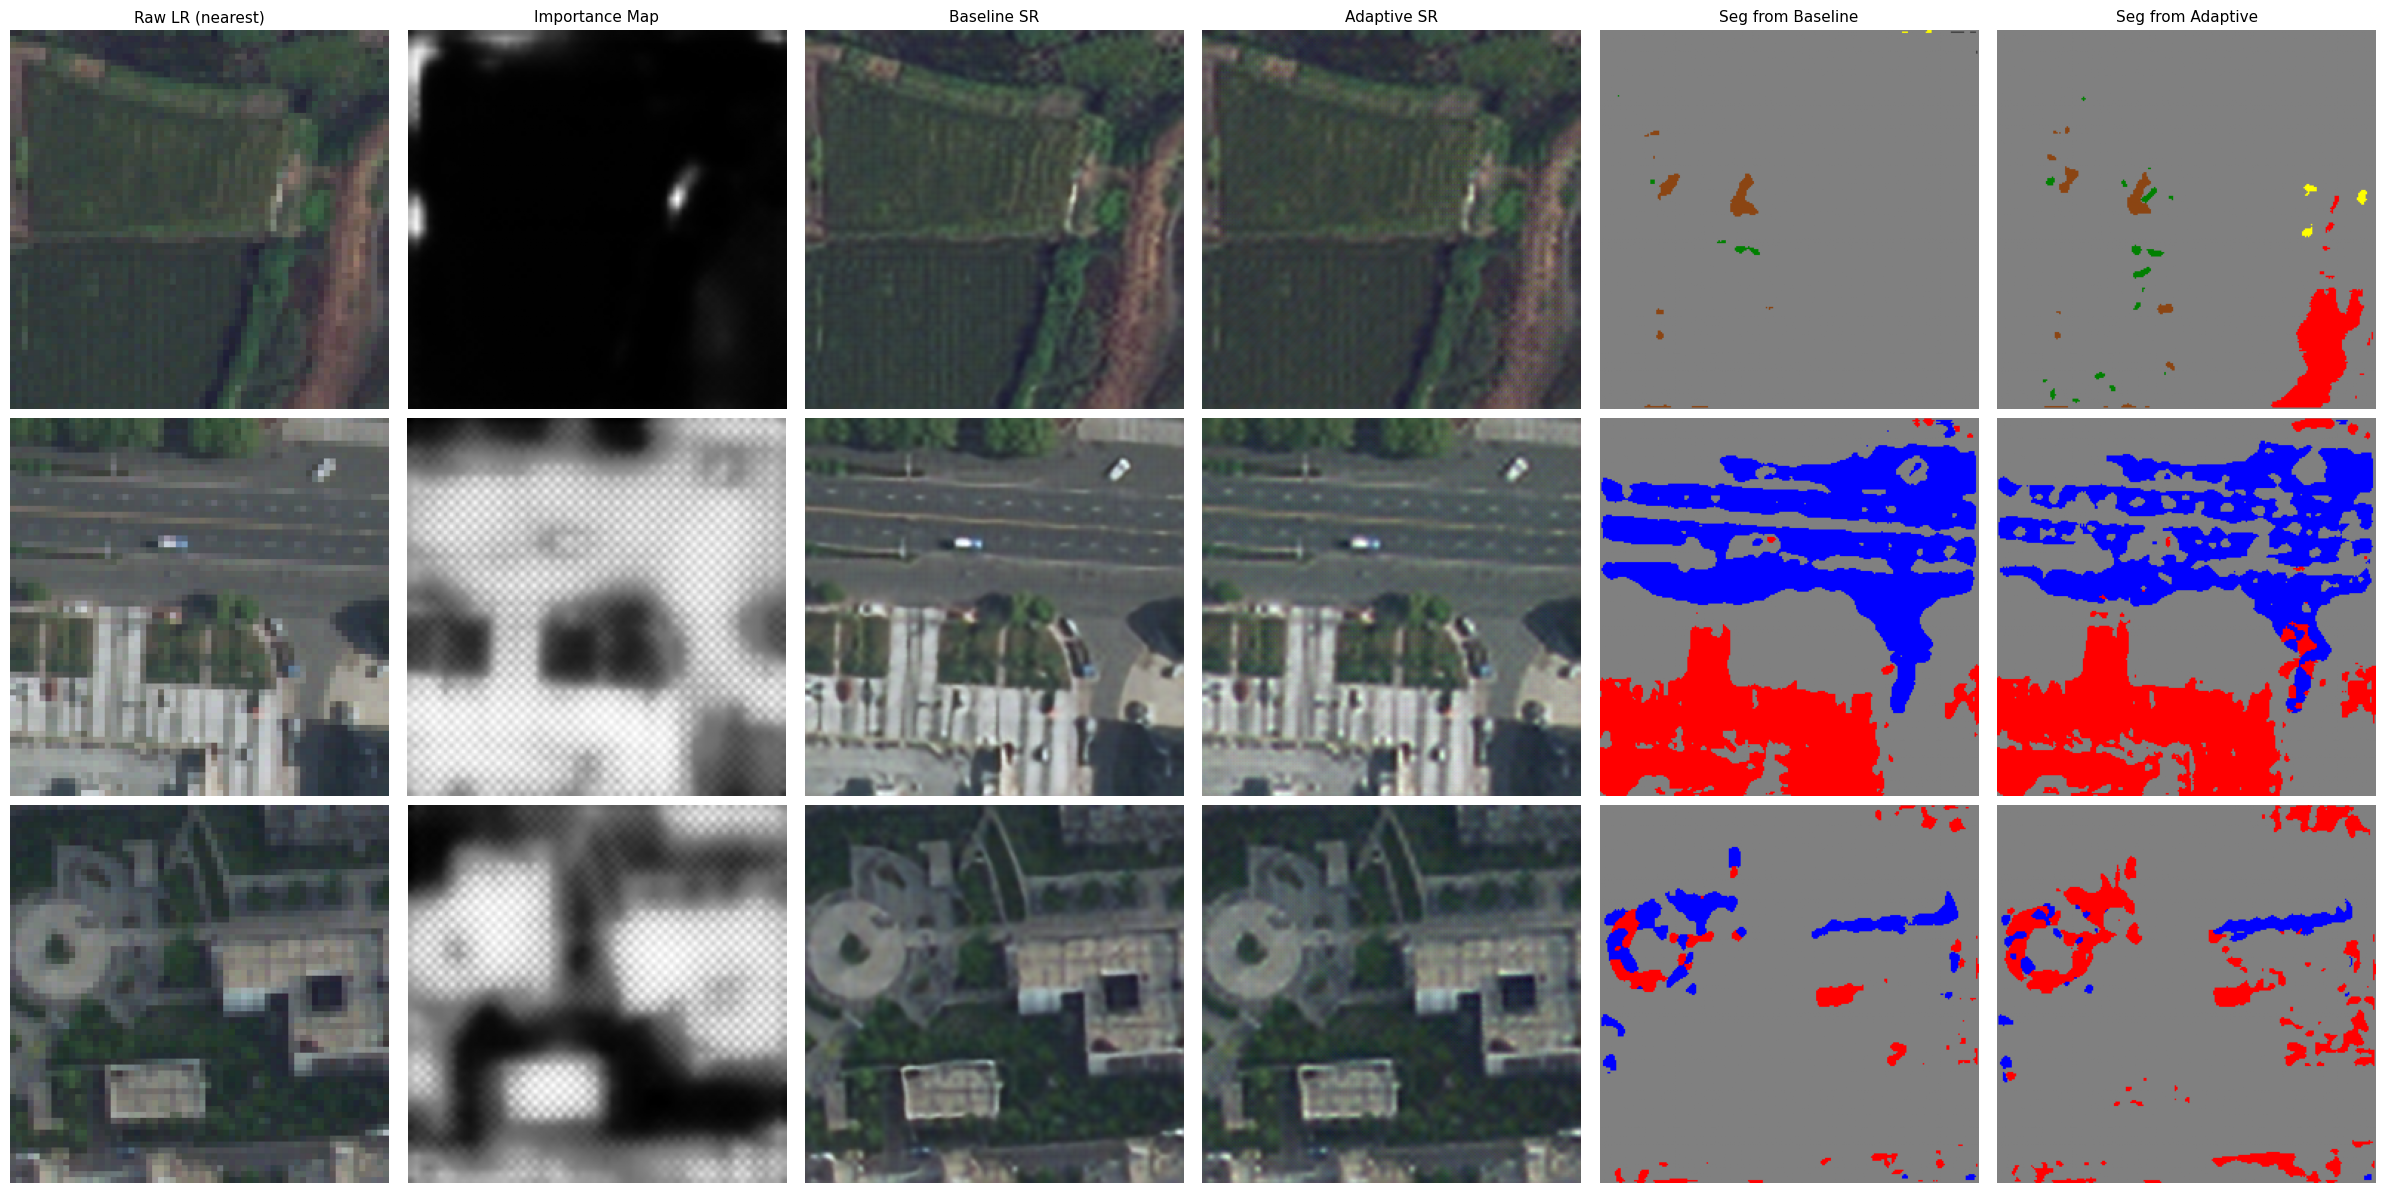

All done. Results saved to /kaggle/working/eval_results.json and final_comparison_grid.png


In [10]:
import matplotlib.pyplot as plt

CLASS_COLORS = np.array([[0,0,0],[128,128,128],[255,0,0],[0,0,255],
                          [139,69,19],[0,128,0],[255,255,0],[64,64,64]]) / 255.0
def colorize_mask(m): return CLASS_COLORS[m]

sample_batch = next(iter(DataLoader(val_dataset, batch_size=3, shuffle=False)))
lr_img = sample_batch['lr'].to(device)
hr_img = sample_batch['hr'].to(device)
mask = sample_batch['mask'].to(device)

with torch.no_grad():
    raw_lr = F.interpolate(lr_img, scale_factor=SCALE, mode='nearest')
    importance = rin(lr_img)
    baseline_sr = baseline_gen(lr_img)
    adaptive_sr = adaptive_gen(lr_img, importance)
    baseline_pred = colorize_mask(seg_model(baseline_sr).argmax(1).cpu().numpy())
    adaptive_pred = colorize_mask(seg_model(adaptive_sr).argmax(1).cpu().numpy())

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
titles = ['Raw LR (nearest)', 'Importance Map', 'Baseline SR', 'Adaptive SR', 'Seg from Baseline', 'Seg from Adaptive']
for row in range(3):
    imgs = [raw_lr[row].permute(1,2,0).cpu().numpy(), importance[row,0].cpu().numpy(),
            baseline_sr[row].permute(1,2,0).cpu().numpy(), adaptive_sr[row].permute(1,2,0).cpu().numpy(),
            baseline_pred[row], adaptive_pred[row]]
    for col, (img, t) in enumerate(zip(imgs, titles)):
        axes[row,col].imshow(img, cmap='gray' if col==1 else None)
        if row==0: axes[row,col].set_title(t, fontsize=11)
        axes[row,col].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("All done. Results saved to /kaggle/working/eval_results.json and final_comparison_grid.png")